<h1>ANALÝZA ZLYHANIA SRDCA U PACIENTOV</h1>
Tento ipython notebook obsahuje celý môj výskum a analýzu datasetu a tréning + evaluáciu modelu. Postup je rozložený do nasledujúcich bodov:

<ol>
<li>Príprava a základná analýza datasetu</li>
<li>Tréning a evaluácia základného modelu</li>
<li>Výsledky základného modelu</li>
<li>Tréning a evaluácia upraveného modelu (Threshold tuning)</li>
<li>Výsledky upraveného modelu</li>
<li>Experiment: Random Forest algoritmus</li>
<li>Výsledky experimentu</li>
<li>Finálne zohodnotenie výskumu</li>
</ol>
<hr>

<h2>1. PRÍPRAVA A ZÁKLADNÁ ANALÝZA DATASETU</h2>
V tejto časti som sa prvýkrát pozrel na dataset

In [1]:
#Importovanie dôležitých modulov pre vizualizáciu a prácu s datasetom a tréning a evaluáciu modelu
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV
from sklearn.metrics import recall_score, classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier

#Reset štýlov pre vizualizácie
plt.style.use('default')

In [2]:
#Nahratie datasetu a jeho rozdelenie do features (f) a label (l)
h_f_data = pd.read_csv("heart_failure_clinical_records_dataset.csv")
l = h_f_data.DEATH_EVENT
f = h_f_data.drop(columns="DEATH_EVENT", inplace=False)

In [3]:
#Zobrazenie prvých 5 pozorovaní alebo "pacientov" a ich parametre. Každý riadok predstavuje jedného pacienta a každý stĺpec iné dáta z pozorovania.
f.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


<h3>Popis jednotlivých stĺpcov v datasete</h3>
<ol>
<li><b>age</b> |                    Vek pacienta</li>
<li><b>sex</b> |                    Muž/žena</li>
<li><b>smoking</b> |                fajčiar/nefajčiar</li>
<li><b>time</b> |                   Čas medzi vyšetreniami po diagnóze</li>
<li><b>anaemia</b> |                Zníženie hemoglobínu alebo počtu červených krviniek (erytrocytov) v krvi, pozitívny/negatívny</li>
<li><b>creatine_phosphokinase</b> | Hladina enzýmu CPK v krvi</li>
<li><b>diabetes</b> |               Pozitívny/negatívny</li>
<li><b>ejection_fraction</b> |      Percento krvi odchádzajúce zo srdca po každom vypumpovaní</li>
<li><b>high_blood_pressure</b> |    Hypertenzia, pozitívny/negatívny</li>
<li><b>platelets</b> |              Počet krvných doštičiek v krvi</li>
<li><b>serum_creatinine</b> |       Odpadová látka v krvi vypúšťaná svalmi a filtrovaná obličkami</li>
<li><b>serum_sodium</b> |           Koncentrácia sodíka v krvi</li>
<li><b>DEATH_EVENT</b> |            Smrť pacienta - pozitívny/negatívny</li>
</ol>

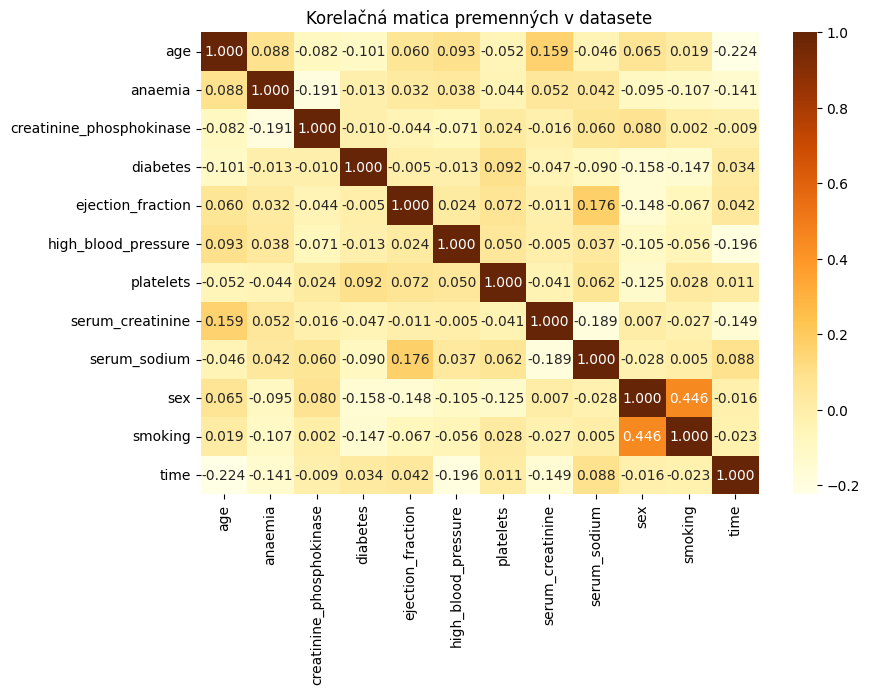

In [4]:
#Zobrazenie korelácií stĺpcov v datasete
plt.figure(figsize=(9, 6))
sns.heatmap(data=f.corr(), cmap="YlOrBr", annot=True, fmt=".3f")
plt.title("Korelačná matica premenných v datasete")
plt.show()

<hr>

<h2>2. TRÉNING A EVALUÁCIA: ZÁKLADNÝ MODEL</h2>
Na počiatočný tréning a evaluáciu som využil Decision Tree. Tento algoritmus v zjednodšenom podaní rozdeľuje dáta podľa features v datasete. V ideálnom prípade by mali byť dáta rozdelené rovnomerne do skupín tak, aby v jednej skupine bolo 100% z jednej class a 0% z druhej. Nižšie som rozdelil dáta na tréningové a testovacie a natrénoval model na testovacích dátach s rôznymi hĺbkami modelu. (Väčšia hĺbka modelu znamená väčšia komplexita. Ideálna hĺbka je max 7-10)

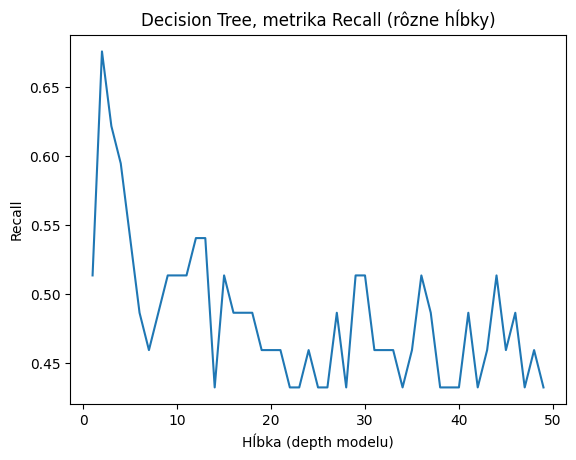

In [5]:
X_train, X_test, y_train, y_test = train_test_split(f, l, test_size=0.3, random_state=42)

recalls = {}
for depth in range(1, 50):
    tree = DecisionTreeClassifier(max_depth=depth, class_weight='balanced')
    tree.fit(X_train, y_train)
    recalls[depth] = recall_score(y_test, tree.predict(X_test))

plt.plot(recalls.keys(), recalls.values())
plt.title("Decision Tree, metrika Recall (rôzne hĺbky)")
plt.xlabel("Hĺbka (depth modelu)")
plt.ylabel("Recall")
plt.show()

Depth: 2
Recall: 0.6756756756756757
              precision    recall  f1-score   support

           0       0.68      0.85      0.76        53
           1       0.67      0.43      0.52        37

    accuracy                           0.68        90
   macro avg       0.67      0.64      0.64        90
weighted avg       0.68      0.68      0.66        90



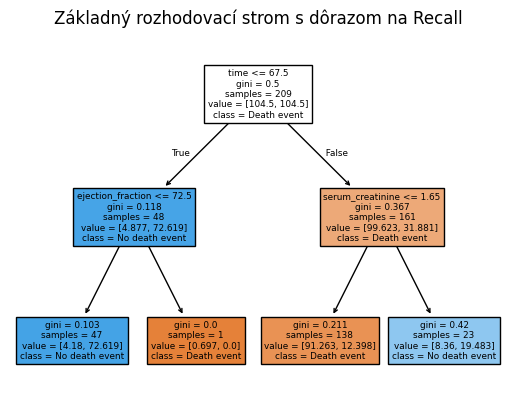

In [6]:
best_depth_recall = {}
for k, v in recalls.items():
    if v == max(recalls.values()):
        best_depth_recall[k] = v
        break
print(f"Depth: {list(best_depth_recall.keys())[0]}\nRecall: {list(best_depth_recall.values())[0]}")
print(classification_report(y_test, tree.predict(X_test)))

tree = DecisionTreeClassifier(max_depth=2, class_weight='balanced')
tree.fit(X_train, y_train)


x_cols = X_train.columns
plot_tree(tree, feature_names=x_cols, class_names=["Death event", "No death event"], filled=True)
plt.title("Základný rozhodovací strom s dôrazom na Recall")
plt.show()

<h2>3. VÝSLEDKY ZÁKLADNÉHO MODELU</h2>
Pri tŕeningu aj evaluácii som sa sústredil hlavne na F1 score a Recall, čo sú dve z metrík udávajúce presnosť modelu. Cieľ modela je klasifikovať čo najviac pacientov ako death_event=1 (pozitívny label), čo znamená smrť, aby im bola dodaná dostatočná starostlivosť v nemocnici.<br><br>

Report zo základného natrénovaného modelu:
<ul>
<li>Recall (label = 0):  85%</li>
<li>Recall (label = 1):  49%</li>
<li>F1 (label = 0):      77%</li>
<li>F1 (label = 1):      57%</li>
</ul>

Na základe metriky Recall model pri testovaní správne rozpoznal len 49% mŕtvych pacientov. Model je v tomto stave orientovaný skôr na rozpoznávanie tých, ktorí prežijú, ako tých, ktorí neprežijú. V tomto momente je žiadúce upraviť, ako sa model rozhoduje, do ktorej triedy zaradí pacienta (parameter Threshold).
<hr>

<h2>4. TRÉNING A EVALUÁCIA: UPRAVENÝ MODEL</h2>
Úprava rozhodovacej línie modelu, ktorá určuje, či bude daný pacient patriť do triedy 1 alebo 0 pomocou TunedThresholdClassivierCV.

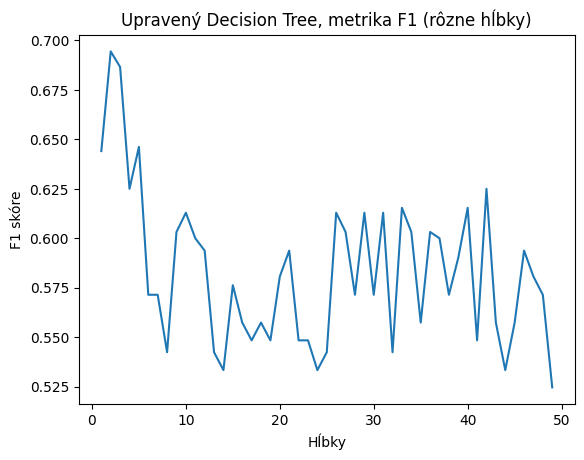

In [7]:
#Natrénovanie modelu s už implementovaným TunedThresholdClassifier, ale s rôznymi hĺbkami stromu a zameraním na čo najlepšie F1 skóre.
f1s = {}
for depth in range(1, 50):
    tuned_tree = TunedThresholdClassifierCV(
    estimator=DecisionTreeClassifier(max_depth=depth, class_weight='balanced'),
    scoring="f1_weighted",
    cv=5
    )

    tuned_tree.fit(X_train, y_train)
    f1s[depth] = f1_score(y_test, tuned_tree.predict(X_test))

#Vizualizácia najlepšej hĺbky stromu v rozmedzí 1-50
plt.plot(f1s.keys(), f1s.values())
plt.title("Upravený Decision Tree, metrika F1 (rôzne hĺbky)")
plt.xlabel("Hĺbky")
plt.ylabel("F1 skóre")
plt.show()

Depth: 2
Recall: 0.6944444444444444
              precision    recall  f1-score   support

           0       0.78      0.81      0.80        53
           1       0.71      0.68      0.69        37

    accuracy                           0.76        90
   macro avg       0.75      0.74      0.75        90
weighted avg       0.75      0.76      0.75        90



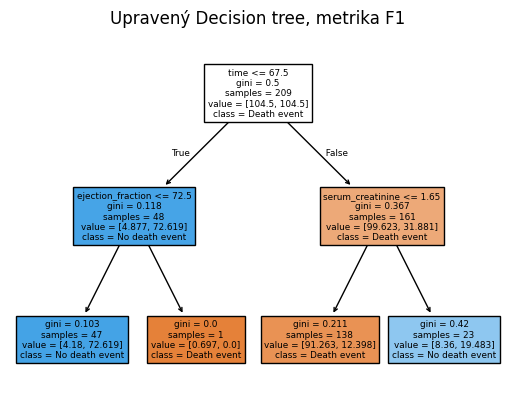

In [8]:
#Nájdenie najlepšej hĺbky stromu
best_depth_f1 = {}
for k, v in f1s.items():
    if v == max(f1s.values()):
        best_depth_f1[k] = v
        break
print(f"Depth: {list(best_depth_f1.keys())[0]}\nRecall: {list(best_depth_f1.values())[0]}")

#Tréning stromu s najideálnejšou hĺbkou + s úpravou rozhodovacej línie
tuned_tree = TunedThresholdClassifierCV(
estimator=DecisionTreeClassifier(max_depth=2, class_weight='balanced'),
scoring="f1_weighted",
cv=5
)
tuned_tree.fit(X_train, y_train)

#Finálna evaluácia modelu a vizualizácia stromu
print(classification_report(y_test, tuned_tree.predict(X_test)))
x_cols = X_train.columns
plot_tree(tuned_tree.estimator_, feature_names=x_cols, class_names=["Death event", "No death event"], filled=True)
plt.title("Upravený Decision tree, metrika F1")
plt.show()

<h2>5. VÝSLEDKY UPRAVENÉHO MODELU</h2>
Pri tréningu druhého, upraveného modelu som sa sústredil na F1 skóre pri predikovaní triedy 1 (smrť). Pri tomto tréningu som sa nesústredil na Recall, keďže po takejto úprave mal model Recall score 100% pre triedu 1 a 0% pre triedu 0 čo znamená, že model vždy predikoval, že pacient zomrie, aj keď bolo jasné, že nie. F1 skóre je preto lepšia metrika, keďže nastavuje rovnováhu medzi klasifikovaním tried.<br><br>

Report z natrénovaného modelu:
<ul>
<li>Recall (label = 0):  81%</li>
<li>Recall (label = 1):  68%</li>
<li>F1 (label = 0):      80%</li>
<li>F1 (label = 1):      69%</li>
</ul>

Model si viedol pri klasifikácii s dôrazom na F1 skóre oveľa lepšie. Recall sa zvýšil zo 49% na 68%, takže model v 68% prípadoch predikuje správne smrť. Model som sa snažil upravovať ďalej, no neviedlo to k ďalším vylepšeniam. Toto je najlepší strom, aký som momentálne dokázal natrénovať.
<hr>

<h2>6. EXPERIMENT: TRÉNING ALGORITMU RANDOM FOREST</h2>
Random forest je "les" vytvorený z viacerých rozhodovacích stromov (decision tree). Rozhodovacie stromy vytvoria svoje štruktúry z rôznych dát z datasetu. Na vstup lesu potom ide jeden pacient, ktorý je daný každému stromu v lese. Následne je klasifikovaný podľa toho, ako sa rozhodne väčšina rozhodovacích stromov.

In [9]:
#Tréning základného modelu
forest = RandomForestClassifier(n_estimators=200, max_leaf_nodes=None, class_weight="balanced", random_state=42)
forest.fit(X_train, y_train)

print(classification_report(y_test, forest.predict(X_test)))

              precision    recall  f1-score   support

           0       0.73      0.92      0.82        53
           1       0.83      0.51      0.63        37

    accuracy                           0.76        90
   macro avg       0.78      0.72      0.72        90
weighted avg       0.77      0.76      0.74        90



In [10]:
#Tréning s dôrazom na F1/Recall
tuned_forest = TunedThresholdClassifierCV(estimator=forest, scoring="f1_weighted", cv=5)
tuned_forest.fit(X_train, y_train)

print(classification_report(y_test, tuned_forest.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80        53
           1       0.72      0.70      0.71        37

    accuracy                           0.77        90
   macro avg       0.76      0.76      0.76        90
weighted avg       0.77      0.77      0.77        90



<h2>7. VÝSLEDKY EXPERIMENTU (RANDOM FOREST)</h2>
Pri tomto experimente som sa zameral na úpravu hyperparametrov ako počet stromov v lese apod. Zároveň som sa zameral na úpravu rozhodovacej línie modelu, s ktorou som mal problém. Tréning základného modelu ukázal pretrvávajúce problémy s klasifikáciou úmrtnosti. Po druhej úprave, kde som upravil rozhodovaciu líniu (threshold) so zameraním na čo najlepšie F1 skóre sa model dostal na uspokojujúce čísla.<br><br>

Report z natrénovaného modelu:
<ul>
<li>Recall (label = 0):  81%</li>
<li>Recall (label = 1):  70%</li>
<li>F1 (label = 0):      80%</li>
<li>F1 (label = 1):      71%</li>
</ul>
<hr>

<h2>8. VÝSLEDKY VÝSKUMU</h2>
V tomto výskume som natrénoval niekoľko inštancií modelu Decision Tree na predikovanie úmrtnosti pacientov na zlyhanie srdca, pričom som sa zameral na metriku Recall a F1 skóre. Ich maximalizovaním som dosiahol, že model klasifikoval častejšie prípady ako úmrtné, čím sa síce znížila jeho presnosť, keďže častejšie vyhodnotil aj neúmrtné prípady ako úmrtné, no zachytil aj menej jasné prípady, ktoré boli stále úmrtné. Potom som pokračoval s experimentálnym tréningom modelu Random Forest, ktorý aj po úpravách ukázal minimálne vylepšenia, ale stále dobrý výsledok.